<a href="https://colab.research.google.com/github/helloohowareyu/Praktikum-Kecerdasan-Artifisial-Lanjut/blob/main/Praktikum_8_K_Means_dan_DBSCAN_Soal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Pengantar Pembelajaran Mesin


---
## Bab 10. Hierarchical Clustering


## 1 ) Persiapan:

   - Pastikan perangkat dan perangkat lunak siap digunakan.
   - Import pustaka yang dibutuhkan (jika belum tersedia):


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp

Untuk uji coba pertama, gunakan dataset sederhana berikut:

In [2]:
data = {'X': [1, 2, 5, 6, 8],
        'Y': [1, 1, 5, 6, 8]}

df = pd.DataFrame(data)
print(df)

   X  Y
0  1  1
1  2  1
2  5  5
3  6  6
4  8  8


## 2 ) Implementasi

a. Menghitung Matriks Jarak

In [4]:
from scipy.spatial.distance import pdist, squareform

jarak = pdist(df, metric='cityblock')
matriks_jarak = squareform(jarak)
print("Matriks Jarak (Manhattan):\n", matriks_jarak)

Matriks Jarak (Manhattan):
 [[ 0.  1.  8. 10. 14.]
 [ 1.  0.  7.  9. 13.]
 [ 8.  7.  0.  2.  6.]
 [10.  9.  2.  0.  4.]
 [14. 13.  6.  4.  0.]]


b. Hierarchical Clustering (Single Linkage & Complete Linkage)

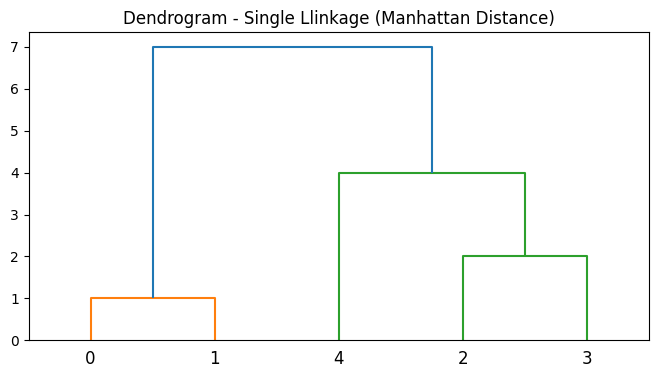

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Single Linkage
linked_single = linkage(df, method='single', metric='cityblock')
plt.figure(figsize=(8, 4))
dendrogram(linked_single,
           labels=df.index,
           orientation='top')
plt.title('Dendrogram - Single Llinkage (Manhattan Distance)')
plt.show()

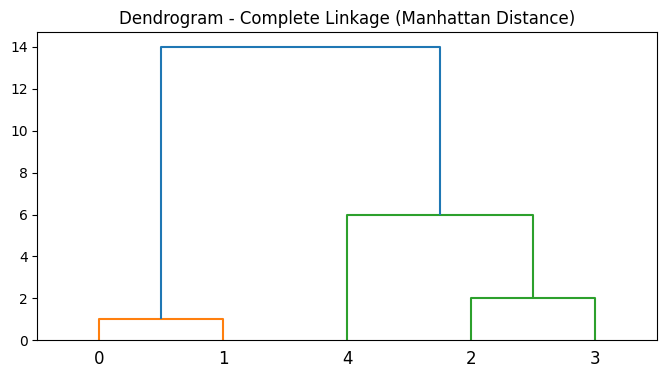

In [6]:
# Complete Linkage

linked_complete = linkage(df, method='complete', metric='cityblock')
plt.figure(figsize=(8, 4))
dendrogram(linked_complete,
           labels=df.index,
           orientation='top')
plt.title('Dendrogram - Complete Linkage (Manhattan Distance)')
plt.show()

c. Menentukan Kelompok (Optional - jika ingin memotong dendogram)

In [7]:
from scipy.cluster.hierarchy import fcluster

# Membagi hasil clustering menjadi 2 cluster
cluster_labels = fcluster(linked_single, 2, criterion='maxclust')
df['Cluster'] = cluster_labels
print(df)

   X  Y  Cluster
0  1  1        1
1  2  1        1
2  5  5        2
3  6  6        2
4  8  8        2


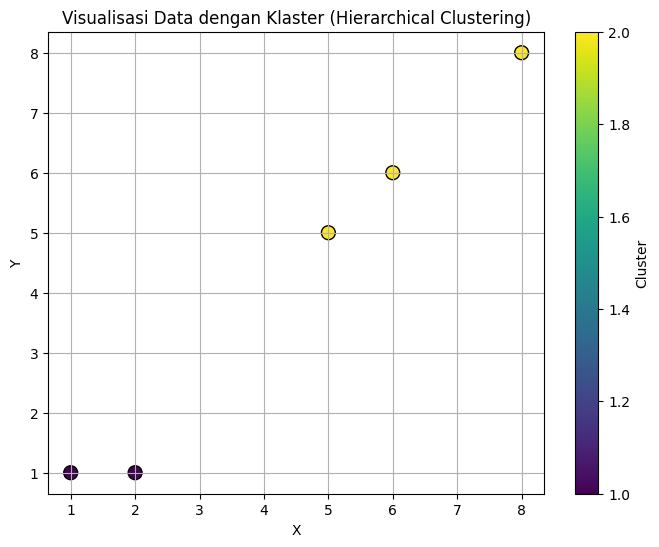

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'], c=df['Cluster'], cmap='viridis', s=100, edgecolors='k')
plt.title('Visualisasi Data dengan Klaster (Hierarchical Clustering)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

## TUGAS

1 ) Jelaskan perbedaan hasil clustering antara metode Single Linkage dan Complete Linkage berdasarkan dendogram yang dihasilkan!

**Jawaban**
1.  **Metode Pengukuran (Linkage):**
    *   **Single Linkage (Nearest Neighbor):** Menghitung jarak antara dua klaster berdasarkan jarak **terdekat** antara anggota-anggotanya. Metode ini cenderung menghasilkan struktur klaster yang memanjang (efek rantai atau *chaining*).
    *   **Complete Linkage (Farthest Neighbor):** Menghitung jarak antara dua klaster berdasarkan jarak **terjauh** antara anggota-anggotanya. Metode ini cenderung menghasilkan klaster yang lebih padat, bulat, dan berukuran serupa.

2.  **Berdasarkan Dendrogram yang Dihasilkan:**
    *   Pada **Single Linkage**, terdapat penggabungan titik-titik (seperti indeks 2, 3, dan 4) terjadi pada tingkat jarak (sumbu Y) yang lebih rendah (Y = 7) dibandingkan Complete Linkage (Y = 14).
    *   Pada **Complete Linkage**, tinggi garis horizontal (jarak penggabungan) lebih besar karena ia harus memastikan semua anggota di satu klaster 'dekat' dengan semua anggota di klaster lainnya berdasarkan kriteria jarak terjauh.

2 ) Uji algoritma Anda pada dataset Iris dan laporkan hasilnya!

In [13]:
# Mengunduh dataset Iris langsung dari repositori GitHub
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
iris_df = pd.read_csv(url)

iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


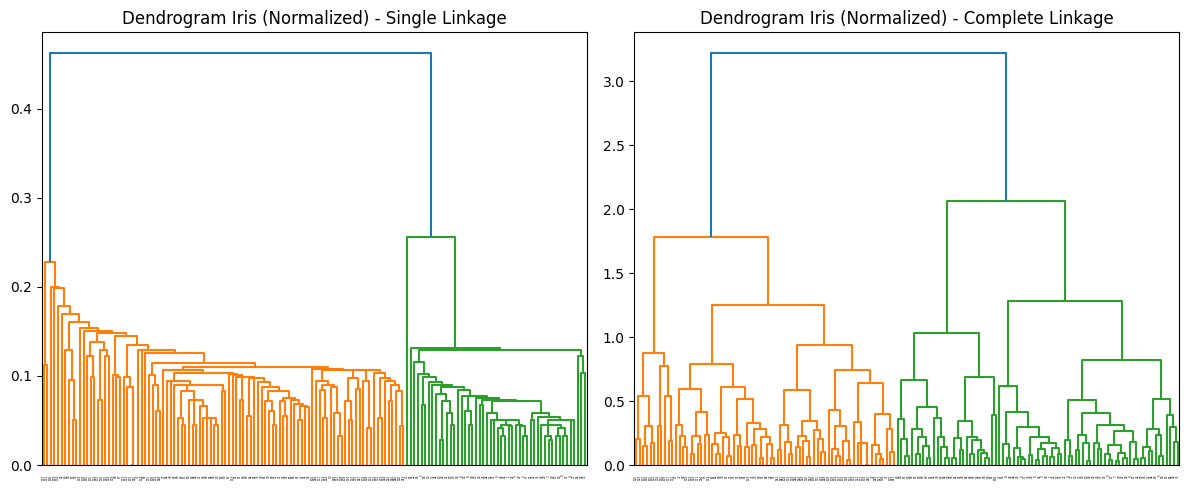

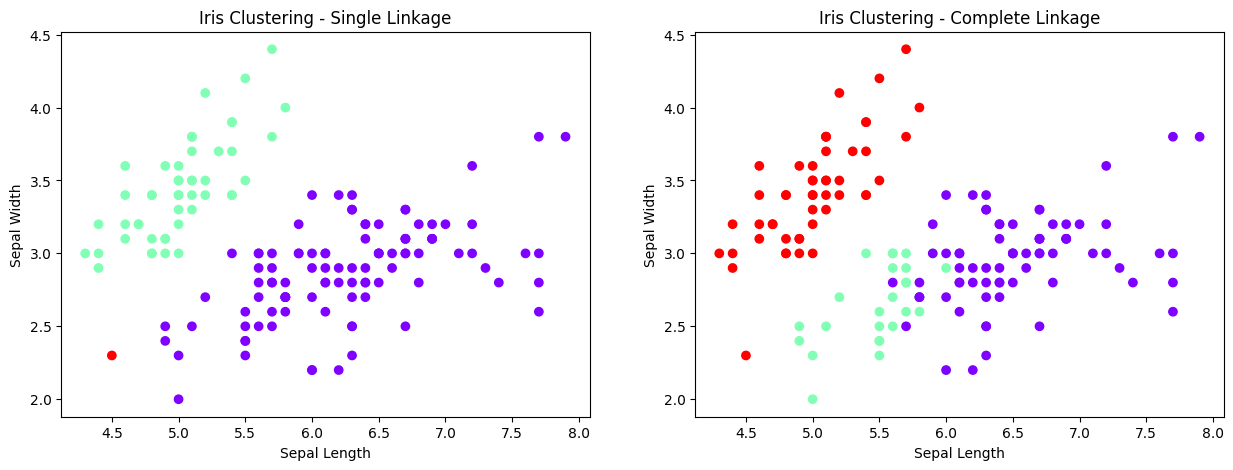

In [23]:
from sklearn.preprocessing import MinMaxScaler

# 1. Preprocessing: Memisahkan fitur numerik
iris_numeric = iris_df.drop(columns=['species'])

# 2. Preprocessing: Normalisasi data (Min-Max Scaling)
scaler = MinMaxScaler()
iris_data_scaled = scaler.fit_transform(iris_numeric)

# 3. Hierarchical Clustering (Single & Complete Linkage)
linked_single = linkage(iris_data_scaled, method='single', metric='euclidean')
linked_complete = linkage(iris_data_scaled, method='complete', metric='euclidean')

# 4. Visualisasi Dendrogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
dendrogram(linked_single_iris,
           labels=iris_df.index,
           leaf_rotation=90.,
           leaf_font_size=2.)
plt.title('Dendrogram Iris (Normalized) - Single Linkage')

plt.subplot(1, 2, 2)
dendrogram(linked_complete_iris,
           labels=iris_df.index,
           leaf_rotation=90.,
           leaf_font_size=2.)
plt.title('Dendrogram Iris (Normalized) - Complete Linkage')

plt.tight_layout()
plt.show()

# 5. Menentukan Kelompok (3 cluster)
iris_df['Cluster_Single'] = fcluster(linked_single_iris, 3, criterion='maxclust')
iris_df['Cluster_Complete'] = fcluster(linked_complete_iris, 3, criterion='maxclust')

# 6. Visualisasi Hasil Clustering (Sepal Length vs Sepal Width)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(iris_df.iloc[:, 0], iris_df.iloc[:, 1], c=iris_df['Cluster_Single'], cmap='rainbow')
plt.title('Iris Clustering - Single Linkage')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.subplot(1, 2, 2)
plt.scatter(iris_df.iloc[:, 0], iris_df.iloc[:, 1], c=iris_df['Cluster_Complete'], cmap='rainbow')
plt.title('Iris Clustering - Complete Linkage')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.show()

3. Analisis kelebihan dan kekurangan metode Hierarchical Clustering dibandingkan K-Means dan DBSCAN!